# Poisson Solver: Validation

Validates `poisson.py`'s `solve_poisson` (direct sparse linear solve of
`laplacian(V) = -rho/eps0`) three ways:

1. **Point charge**: fit the numerical `V(r)` to the actual 2D Green's
   function for Poisson's equation (logarithmic, not the 3D `1/r`
   Coulomb form -- this is a 2D grid solve).
2. **Method of manufactured solutions**: a known analytic `V_exact`
   (avoiding the point charge's singularity) to cleanly check the
   convergence order.
3. **Parallel-plate capacitor**: the field between two fixed-potential
   plates, compared to the ideal uniform-field approximation.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import poisson as p

os.makedirs('media', exist_ok=True)

## Point charge vs. the 2D log Green's function

A 2D grid solve of Poisson's equation is physically a cross-section of an
infinite line charge, not an isolated 3D point charge -- its potential
falls off as `-q/(2*pi*eps0) * ln(r)`, not `1/r`. Fitting the numerical
`V(r)` (away from the singular source cell and the grounded boundary) to
`A*ln(r) + B` and comparing `A` to that closed-form coefficient is the
correct check.

fitted V(r) = A*ln(r) + B: A=-0.16089  (expected -0.15915)
relative error: 0.011
PASS: point-charge potential matches the 2D Poisson Green's function.


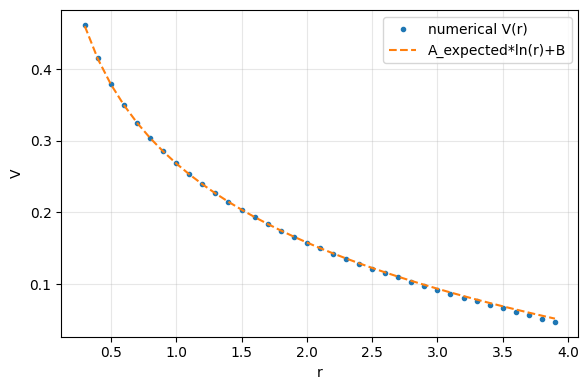

In [2]:
N = 101
dx = dy = 0.1
q = 1.0
eps0 = 1.0

rho = np.zeros((N, N))
ci, cj = N // 2, N // 2
rho[ci, cj] = q / (dx * dy)  # point charge as a density spike (charge per cell area)

fixed_mask = np.zeros((N, N), dtype=bool)
fixed_mask[0, :] = fixed_mask[-1, :] = fixed_mask[:, 0] = fixed_mask[:, -1] = True
fixed_values = np.zeros((N, N))

V = p.solve_poisson(rho, dx, dy, fixed_mask, fixed_values, eps0=eps0)

x = (np.arange(N) - ci) * dx
r = np.abs(x[ci + 3:ci + 40])          # skip the singular cell and stay well inside the grounded box
V_r = V[ci + 3:ci + 40, cj]
A, B = np.polyfit(np.log(r), V_r, 1)
A_expected = -q / (2 * np.pi * eps0)
print(f'fitted V(r) = A*ln(r) + B: A={A:.5f}  (expected {A_expected:.5f})')
rel_err = abs(A - A_expected) / abs(A_expected)
print(f'relative error: {rel_err:.3f}')
assert rel_err < 0.03, 'point-charge potential does not match the 2D log Green\'s function'
print('PASS: point-charge potential matches the 2D Poisson Green\'s function.')

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(r, V_r, 'o', markersize=3, label='numerical V(r)')
ax.plot(r, A_expected * np.log(r) + B, '--', label='A_expected*ln(r)+B')
ax.set_xlabel('r'); ax.set_ylabel('V'); ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('media/point_charge_potential.png', dpi=150, bbox_inches='tight')
plt.show()

## Convergence: method of manufactured solutions

`V_exact = sin(pi*x/Lx)*sin(pi*y/Ly)` is an eigenfunction of the
Laplacian, so its source `rho` has a simple closed form and `V_exact=0`
on the domain boundary already -- avoiding the point charge's
singularity gives a clean 2nd-order convergence measurement for the
5-point stencil.

N=21: dx=0.0500  rms error=9.803e-04
N=41: dx=0.0250  rms error=2.508e-04


N=81: dx=0.0125  rms error=6.347e-05


N=161: dx=0.0063  rms error=1.596e-05
error ratios on halving dx: ['3.91', '3.95', '3.98'] (expect ~4 for 2nd-order convergence)
PASS: solve_poisson converges at 2nd order.


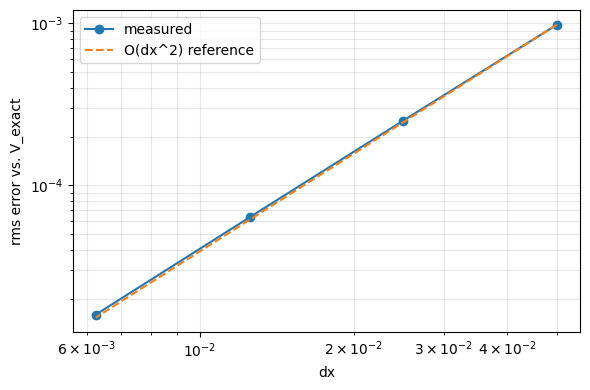

In [3]:
Lx, Ly = 1.0, 1.0
Ns = [21, 41, 81, 161]
errors = []
for N in Ns:
    dx, dy = Lx / (N - 1), Ly / (N - 1)
    x, y = np.arange(N) * dx, np.arange(N) * dy
    X, Y = np.meshgrid(x, y, indexing='ij')
    V_exact = np.sin(np.pi * X / Lx) * np.sin(np.pi * Y / Ly)
    rho = np.pi**2 * (1 / Lx**2 + 1 / Ly**2) * V_exact  # laplacian(V_exact) = -rho (eps0=1)

    fixed_mask = np.zeros((N, N), dtype=bool)
    fixed_mask[0, :] = fixed_mask[-1, :] = fixed_mask[:, 0] = fixed_mask[:, -1] = True
    fixed_values = np.zeros((N, N))
    V = p.solve_poisson(rho, dx, dy, fixed_mask, fixed_values)
    err = np.sqrt(np.mean((V - V_exact)**2))
    errors.append(err)
    print(f'N={N}: dx={dx:.4f}  rms error={err:.3e}')

ratios = [errors[i] / errors[i + 1] for i in range(len(errors) - 1)]
print(f'error ratios on halving dx: {[f"{r:.2f}" for r in ratios]} (expect ~4 for 2nd-order convergence)')
assert all(3.5 < r < 4.5 for r in ratios), 'convergence rate is not consistent with the expected 2nd order'
print('PASS: solve_poisson converges at 2nd order.')

fig, ax = plt.subplots(figsize=(6, 4))
dxs = [Lx / (N - 1) for N in Ns]
ax.loglog(dxs, errors, 'o-', label='measured')
ax.loglog(dxs, errors[0] * (np.array(dxs) / dxs[0])**2, '--', label='O(dx^2) reference')
ax.set_xlabel('dx'); ax.set_ylabel('rms error vs. V_exact'); ax.legend(); ax.grid(alpha=0.3, which='both')
fig.tight_layout()
fig.savefig('media/poisson_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

## Parallel-plate capacitor

Two fixed-potential strips (`+1`, `-1`) separated by distance `d`. Away
from the plate edges, the field should approach the ideal
parallel-plate value `E ~ (V1-V2)/d`.

ideal parallel-plate |E| = 1.0000
measured |E| between plates = 0.9878
measured field leaking along the plates (should be small) = 8.34e-15
PASS: measured field matches the ideal parallel-plate approximation within 1.2%.


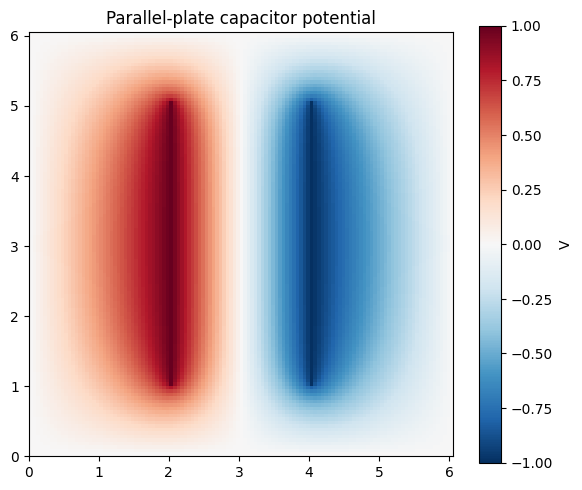

In [4]:
N = 121
dx = dy = 0.05
rho = np.zeros((N, N))

fixed_mask = np.zeros((N, N), dtype=bool)
fixed_values = np.zeros((N, N))
plate_sep_idx = 40
mid = N // 2
i_top, i_bot = mid - plate_sep_idx // 2, mid + plate_sep_idx // 2
x0, x1 = 20, N - 20
fixed_mask[i_top, x0:x1] = True; fixed_values[i_top, x0:x1] = 1.0
fixed_mask[i_bot, x0:x1] = True; fixed_values[i_bot, x0:x1] = -1.0
fixed_mask[0, :] = fixed_mask[-1, :] = fixed_mask[:, 0] = fixed_mask[:, -1] = True  # grounded outer box

V = p.solve_poisson(rho, dx, dy, fixed_mask, fixed_values)
Ex, Ey = p.efield(V, dx, dy)

d = plate_sep_idx * dy
E_ideal = (1.0 - (-1.0)) / d
mid_row = (i_top + i_bot) // 2
E_measured = np.mean(np.abs(Ex[mid_row, x0 + 15:x1 - 15]))  # field component across the plate separation (axis 0)
E_cross_leak = np.mean(np.abs(Ey[mid_row, x0 + 15:x1 - 15]))  # should be near zero (no field along the plates)

print(f'ideal parallel-plate |E| = {E_ideal:.4f}')
print(f'measured |E| between plates = {E_measured:.4f}')
print(f'measured field leaking along the plates (should be small) = {E_cross_leak:.2e}')
rel_err = abs(E_measured - E_ideal) / E_ideal
assert rel_err < 0.05, 'measured capacitor field does not match the parallel-plate approximation'
print(f'PASS: measured field matches the ideal parallel-plate approximation within {rel_err:.1%}.')

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(V.T, cmap='RdBu_r', origin='lower', extent=(0, N * dx, 0, N * dy))
plt.colorbar(im, ax=ax, label='V')
ax.set_title('Parallel-plate capacitor potential')
fig.tight_layout()
fig.savefig('media/capacitor_potential.png', dpi=150, bbox_inches='tight')
plt.show()